# Maximally-localized Wannier functions for a selected range of bands

`h.get_wannier_hamiltonian(bands=[a,b], nk=...)` builds maximally-localized Wannier functions
(MLWFs) for a fixed, contiguous range of bands $[a,b]$ (0-indexed, both ends inclusive,
Wannierized jointly as one group -- there is no band disentanglement), via the `wannierpy`
pure-Python Wannier90 port bundled at `src/pyqula/wanniertk/wannierpy/`. The functions are
found by minimizing the Marzari-Vanderbilt total spread functional

$$\Omega = \sum_n \left[\langle r^2\rangle_n - \langle \mathbf{r}\rangle_n^2\right]$$

over gauge choices consistent with the selected bands, and the method returns a new, smaller
`Hamiltonian` whose real-space hoppings exactly reproduce that band subspace on the
wannierization k-mesh (see the next notebook).

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

Number of Wannier functions: 1
Wannier centres (Cartesian):
 [[ 5.00000000e-01 -2.02384406e-17 -1.59210209e-32]]
Wannier spreads: [0.32057843]
Total spread Omega: 0.3205784260742456


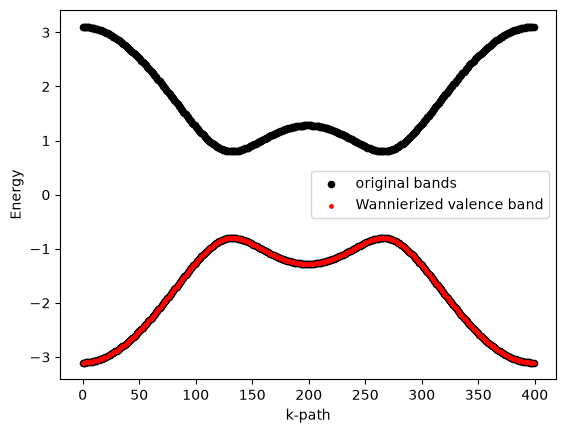

In [2]:
hwan = None
g = geometry.honeycomb_lattice()
h = g.get_hamiltonian(has_spin=False)
h.add_onsite([0.8,-0.8]) # sublattice potential opens a gap -- non-trivial valence band

# Wannierize just the lowest (valence) band -- bands=[0,0] selects band index 0 at
# every k-point of a 12x12 wannierization mesh
hwan = h.get_wannier_hamiltonian(bands=[0,0],nk=12)

print("Number of Wannier functions:",hwan.intra.shape[0])
print("Wannier centres (Cartesian):\n",hwan.wannier_centres)
print("Wannier spreads:",hwan.wannier_spreads)
print("Total spread Omega:",hwan.wannier_spread_total)

(k,e) = h.get_bands(write=False)
(kw,ew) = hwan.get_bands(write=False)

plt.scatter(k,e,c="black",s=20,label="original bands")
plt.scatter(kw,ew,c="red",s=6,label="Wannierized valence band")
plt.xlabel("k-path")
plt.ylabel("Energy")
plt.legend()
plt.show()